# Checkpoint 2: Alzheimer's MRI Classification Modeling<br>
<br>
This notebook implements two models to classify MRI scans into four stages:<br>
1. A Custom Convolutional Neural Network (CNN) built from scratch.<br>
2. Transfer Learning using a pre-trained model (MobileNetV2).<br>
<br>
We will load the data, build/compile/train each model, and visualize the training history (accuracy and loss).

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
# Or VGG16, ResNet50, etc.
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image_dataset_from_directory

In [2]:
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))
print("Is Metal enabled?", tf.config.experimental.list_physical_devices('GPU')[0].device_type == 'METAL' if tf.config.experimental.list_physical_devices('GPU') else False)

if tf.config.experimental.list_physical_devices('GPU'):
    print("Using GPU acceleration")
    # Optional: Configure GPU memory growth
    for gpu in tf.config.experimental.list_physical_devices('GPU'):
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("GPU not available, using CPU")

TensorFlow version: 2.18.0
Num GPUs Available:  1
Is Metal enabled? False
Using GPU acceleration


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os

## 1. Setup and Configuration

In [4]:
DATASET_DIR = "/Users/williamosborne/.cache/kagglehub/datasets/abdullahtauseef2003/adni-4c-alzheimers-mri-classification-dataset/versions/1/AugmentedAlzheimerDataset"

Image parameters (based on your Checkpoint 1 EDA)

In [5]:
IMG_HEIGHT = 190  # [cite: 14]
IMG_WIDTH = 200  # [cite: 14]
IMG_CHANNELS_GRAY = 1  # Grayscale images [cite: 16]
IMG_CHANNELS_RGB = 3  # Required for many pre-trained models
IMG_SHAPE_GRAY = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS_GRAY)
IMG_SHAPE_RGB = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS_RGB)

Training parameters (adjust as needed)

In [6]:
BATCH_SIZE = 32
EPOCHS_CUSTOM_CNN = 15  # Start with fewer epochs, increase if needed
EPOCHS_TRANSFER = 10    # Fewer epochs often needed for fine-tuning

Dataset parameters

In [7]:
CLASS_NAMES = ["AD", "CN", "EMCI", "LMCI"]  # [cite: 3]
NUM_CLASSES = len(CLASS_NAMES)
VALIDATION_SPLIT = 0.2  # Use 20% of data for validation

## 2. Load and Prepare Data<br>
use image_dataset_from_directory to load the images. It automatically infers class labels from the directory structure and splits data into training and validation sets.

In [8]:
train_ds_gray, val_ds_gray = image_dataset_from_directory(
    DATASET_DIR,
    labels='inferred',
    label_mode='categorical',  # for multi-class classification
    class_names=CLASS_NAMES,
    validation_split=VALIDATION_SPLIT,
    subset="both",
    seed=123,  # for reproducibility
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode='grayscale'  # Load as grayscale [cite: 16]
)

Found 33984 files belonging to 4 classes.
Using 27188 files for training.
Using 6796 files for validation.


2025-04-19 12:06:46.739647: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-04-19 12:06:46.739684: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2025-04-19 12:06:46.739687: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
I0000 00:00:1745078806.739706 13222484 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1745078806.739727 13222484 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


--- Load Data for Transfer Learning (RGB) ---<br>
Most pre-trained models expect 3 color channels.<br>
We'll load as RGB; image_dataset_from_directory handles conversion if source is grayscale.

In [9]:
train_ds_rgb, val_ds_rgb = image_dataset_from_directory(
    DATASET_DIR,
    labels='inferred',
    label_mode='categorical',
    class_names=CLASS_NAMES,
    validation_split=VALIDATION_SPLIT,
    subset="both",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode='rgb'  # Load/convert to RGB for pre-trained model
)

Found 33984 files belonging to 4 classes.
Using 27188 files for training.
Using 6796 files for validation.


In [10]:
print("Class names (Grayscale):", train_ds_gray.class_names)
print("Class names (RGB):", train_ds_rgb.class_names)

Class names (Grayscale): ['AD', 'CN', 'EMCI', 'LMCI']
Class names (RGB): ['AD', 'CN', 'EMCI', 'LMCI']


2025-04-19 12:06:47.366372: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


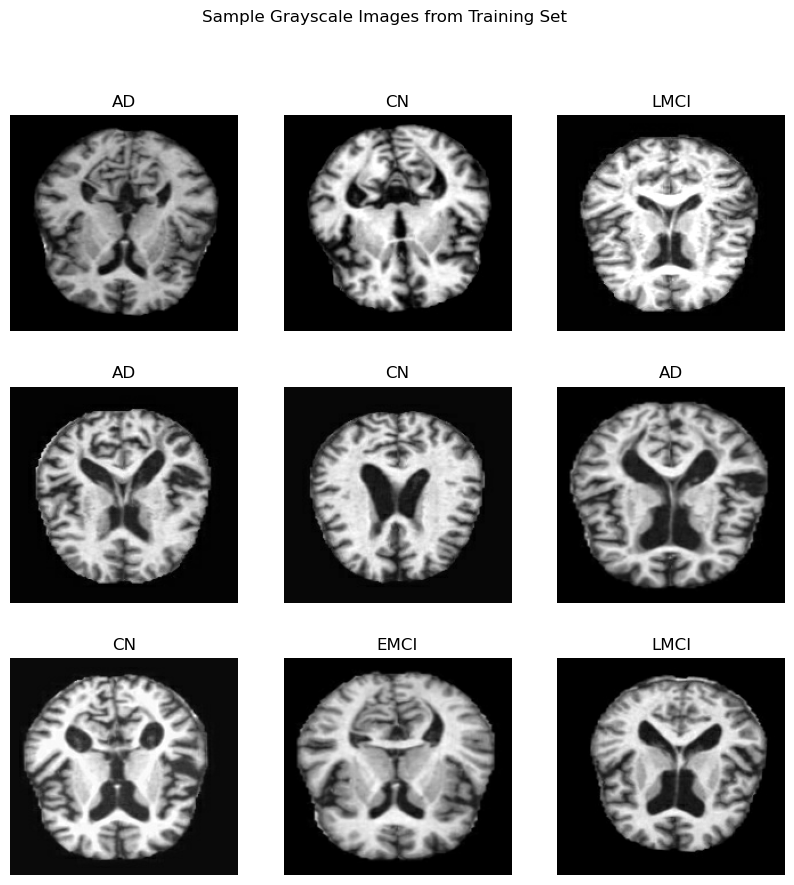

In [11]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds_gray.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # Squeeze removes the channel dimension for grayscale display
        plt.imshow(np.squeeze(images[i].numpy().astype("uint8")), cmap='gray')
        # Find the index of the '1' in the one-hot encoded label
        label_index = np.argmax(labels[i])
        plt.title(train_ds_gray.class_names[label_index])
        plt.axis("off")
plt.suptitle("Sample Grayscale Images from Training Set")
plt.show()

2025-04-19 12:06:47.700085: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


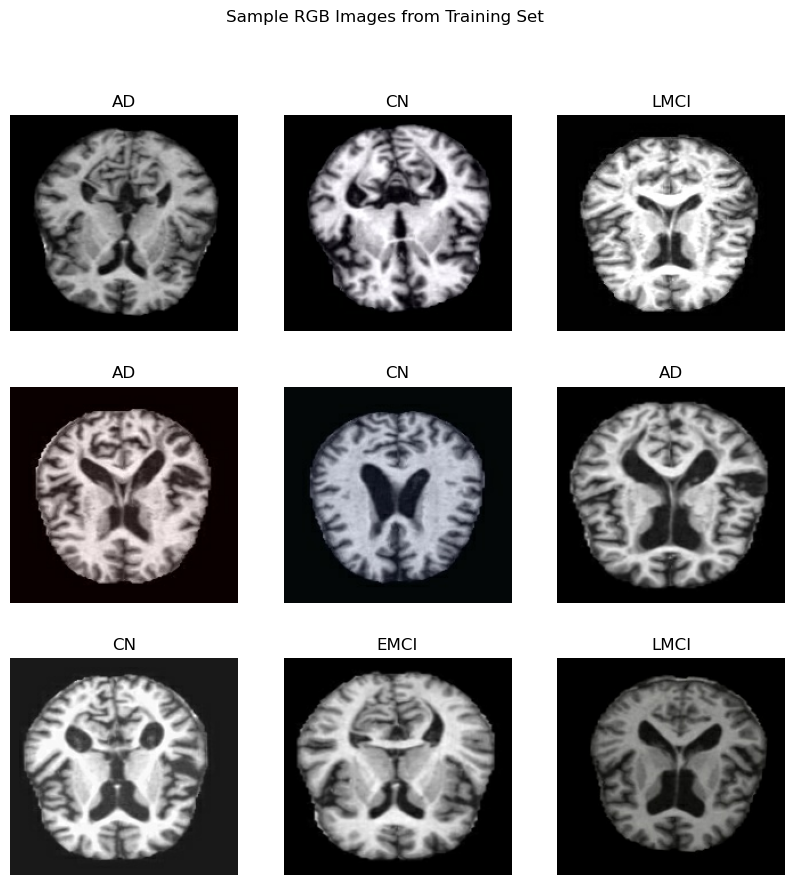

In [12]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds_rgb.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_index = np.argmax(labels[i])
        plt.title(train_ds_rgb.class_names[label_index])
        plt.axis("off")
plt.suptitle("Sample RGB Images from Training Set")
plt.show()

## 3. Configure Data Performance<br>
Use buffered prefetching to load images from disk without I/O blocking.

In [13]:
AUTOTUNE = tf.data.AUTOTUNE

In [14]:
train_ds_gray = train_ds_gray.cache().shuffle(
    1000).prefetch(buffer_size=AUTOTUNE)
val_ds_gray = val_ds_gray.cache().prefetch(buffer_size=AUTOTUNE)

In [15]:
train_ds_rgb = train_ds_rgb.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds_rgb = val_ds_rgb.cache().prefetch(buffer_size=AUTOTUNE)

## 4. Model 1: Custom CNN from Scratch


Normalization layer adapted to grayscale input range [0, 255]<br>
Based on Checkpoint 1, pixel values were normalized to [0,1],<br>
but image_dataset_from_directory loads them a [0, 255].<br>
rescale here.

In [ ]:
aug = tf.keras.Sequential([
    layers.RandomRotation(0.10),         # ±18°
    layers.RandomZoom(height_factor=0.1, width_factor=0.1),
    layers.RandomTranslation(0.10, 0.10),
    layers.RandomContrast(0.20),
    layers.RandomFlip("horizontal"),     
])

kernel_regularizer = tf.keras.regularizers.l2(1e-4)


In [ ]:
def residual_block(x, filters, downsample=False):
    shortcut = x #resnet part (shortcut)
    x = layers.Conv2D(filters, (3, 3), padding='same', kernel_regularizer=kernel_regularizer, strides=(2 if downsample else 1))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    x = layers.Conv2D(filters, (3, 3), padding='same', kernel_regularizer=kernel_regularizer)(x)
    x = layers.BatchNormalization()(x)
    
    if downsample:
        shortcut = layers.Conv2D(filters, (1, 1), strides=2, kernel_regularizer=kernel_regularizer)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x

inputs = tf.keras.Input(shape=IMG_SHAPE_GRAY)
x = aug(inputs)
x = layers.Rescaling(1.0/255)(inputs)

x = layers.Conv2D(32, (7, 7), strides=2, padding='same', kernel_regularizer=kernel_regularizer)(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPool2D((3, 3), strides=2, padding='same')(x)

for filters in [32, 48, 64, 96]:
    x = residual_block(x, filters, downsample=(filters != 32))
    x = residual_block(x, filters)
# Final layers
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=kernel_regularizer)(x)
x = layers.Dropout(0.5)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)

# Build and compile
model_custom_cnn = models.Model(inputs, out)
model_custom_cnn.compile(    optimizer=tf.keras.optimizers.AdamW(1e-3, weight_decay=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05), metrics=['accuracy'])

In [18]:
model_custom_cnn.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 190, 200,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 190, 200,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 95, 100,   │      1,600 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 95, 100,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 95, 100,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 48, 50,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 48, 50,    │      9,248 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 50,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 48, 50,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 48, 50,    │      9,248 │ re_lu_1[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 50,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 48, 50,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 48, 50,    │          0 │ add[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 48, 50,    │      9,248 │ re_lu_2[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 50,    │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 48, 50,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 48, 50,    │      9,248 │ re_lu_3[0][0]   

 Total params: 599,444 (2.29 MB)

 Trainable params: 597,044 (2.28 MB)

 Non-trainable params: 2,400 (9.38 KB)

### Train the Custom CNN

In [19]:
print("Training Custom CNN...")
history_custom_cnn = model_custom_cnn.fit(
    train_ds_gray,
    validation_data=val_ds_gray,
    epochs=EPOCHS_CUSTOM_CNN
)
print("Custom CNN Training Complete.")

Training Custom CNN...
Epoch 1/15


2025-04-19 12:06:50.011588: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


850/850 ━━━━━━━━━━━━━━━━━━━━ 131s 145ms/step - accuracy: 0.4815 - loss: 1.3216 - val_accuracy: 0.5302 - val_loss: 1.4245
Epoch 2/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 121s 142ms/step - accuracy: 0.6991 - loss: 0.8856 - val_accuracy: 0.5893 - val_loss: 1.2281
Epoch 3/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 127s 149ms/step - accuracy: 0.7783 - loss: 0.7619 - val_accuracy: 0.6293 - val_loss: 1.1648
Epoch 4/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 137s 161ms/step - accuracy: 0.8384 - loss: 0.6610 - val_accuracy: 0.6594 - val_loss: 1.1960
Epoch 5/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 131s 154ms/step - accuracy: 0.8761 - loss: 0.5948 - val_accuracy: 0.7824 - val_loss: 0.7545
Epoch 6/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 131s 154ms/step - accuracy: 0.9042 - loss: 0.5504 - val_accuracy: 0.7372 - val_loss: 0.9881
Epoch 7/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 130s 153ms/step - accuracy: 0.9188 - loss: 0.5274 - val_accuracy: 0.8380 - val_loss: 0.6806
Epoch 8/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 127s 149ms/step - accuracy: 0.9327 - loss: 0.50

In [30]:
model_custom_cnn.save("custom_model.keras")

Preprocessing layer specific to MobileNetV2 (scales input to [-1, 1])

In [20]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
rescale_transfer = layers.Rescaling(1./127.5, offset=-1)  # Scale to [-1, 1]

Load the base model (pre-trained on ImageNet)<br>
include_top=False removes the final classification layer

In [21]:
base_model = MobileNetV2(input_shape=IMG_SHAPE_RGB,
                         include_top=False,
                         weights='imagenet')

/var/folders/tf/b53phpyj4wx950j43xmml5300000gn/T/ipykernel_50612/3971932662.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=IMG_SHAPE_RGB,


Freeze the base model layers

In [22]:
base_model.trainable = False

Build the new model

In [23]:
inputs = tf.keras.Input(shape=IMG_SHAPE_RGB)
x = preprocess_input(inputs)  # Use the specific preprocessing
# x = rescale_transfer(inputs) # Alternative if preprocess_input causes issues
x = base_model(x, training=False)  # Run base model in inference mode
x = layers.GlobalAveragePooling2D()(x)  # Pool features
x = layers.Dropout(0.3)(x)  # Regularization
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(
    x)  # New classifier head

In [24]:
model_transfer = tf.keras.Model(inputs, outputs)

In [25]:
model_transfer.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),  # Start with Adam
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
model_transfer.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 190, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 190, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 190, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 6, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Train the Transfer Learning Model (Classifier Head Only First)

In [27]:
print("Training Transfer Learning Model (Head Only)...")
history_transfer_head = model_transfer.fit(
    train_ds_rgb,
    validation_data=val_ds_rgb,
    epochs=EPOCHS_TRANSFER  # Usually requires fewer epochs for the head
)
print("Transfer Learning (Head Only) Training Complete.")

Training Transfer Learning Model (Head Only)...
Epoch 1/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - accuracy: 0.4620 - loss: 1.2356 - val_accuracy: 0.5703 - val_loss: 0.9568
Epoch 2/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 36s 43ms/step - accuracy: 0.6074 - loss: 0.9007 - val_accuracy: 0.6753 - val_loss: 0.7705
Epoch 3/10
849/850 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6385 - loss: 0.8335

KeyboardInterrupt: 

### Fine-tuning the Transfer Learning Model<br>


In [ ]:
base_model.trainable = True
fine_tune_at = 100 
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False
  
model_transfer.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_transfer.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 190, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 190, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 190, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 6, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 1,866,564 (7.12 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [ ]:
fine_tune_epochs = 10
total_epochs = EPOCHS_TRANSFER + fine_tune_epochs

history_fine_tune = model_transfer.fit(
    train_ds_rgb,
    epochs=total_epochs,
    initial_epoch=history_transfer_head.epoch[-1] + 1,
    validation_data=val_ds_rgb
)

Epoch 11/20
850/850 ━━━━━━━━━━━━━━━━━━━━ 110s 122ms/step - accuracy: 0.4859 - loss: 2.8485 - val_accuracy: 0.6733 - val_loss: 0.7631
Epoch 12/20
850/850 ━━━━━━━━━━━━━━━━━━━━ 101s 119ms/step - accuracy: 0.6378 - loss: 0.9036 - val_accuracy: 0.7023 - val_loss: 0.6891
Epoch 13/20
850/850 ━━━━━━━━━━━━━━━━━━━━ 102s 120ms/step - accuracy: 0.7140 - loss: 0.6671 - val_accuracy: 0.7521 - val_loss: 0.5815
Epoch 14/20
850/850 ━━━━━━━━━━━━━━━━━━━━ 104s 122ms/step - accuracy: 0.7662 - loss: 0.5409 - val_accuracy: 0.7940 - val_loss: 0.4961
Epoch 15/20
850/850 ━━━━━━━━━━━━━━━━━━━━ 105s 123ms/step - accuracy: 0.8116 - loss: 0.4568 - val_accuracy: 0.8170 - val_loss: 0.4434
Epoch 16/20
850/850 ━━━━━━━━━━━━━━━━━━━━ 105s 124ms/step - accuracy: 0.8445 - loss: 0.3773 - val_accuracy: 0.8437 - val_loss: 0.3905
Epoch 17/20
850/850 ━━━━━━━━━━━━━━━━━━━━ 102s 120ms/step - accuracy: 0.8810 - loss: 0.3071 - val_accuracy: 0.8543 - val_loss: 0.3665
Epoch 18/20
850/850 ━━━━━━━━━━━━━━━━━━━━ 102s 120ms/step - accuracy: 

## 6. Visualize Training Results

In [28]:
def plot_history(history, model_name):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)
    plt.figure(figsize=(14, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
    plt.title(f'Training and Validation Accuracy\n({model_name})')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title(f'Training and Validation Loss\n({model_name})')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Plotting Custom CNN Training History...


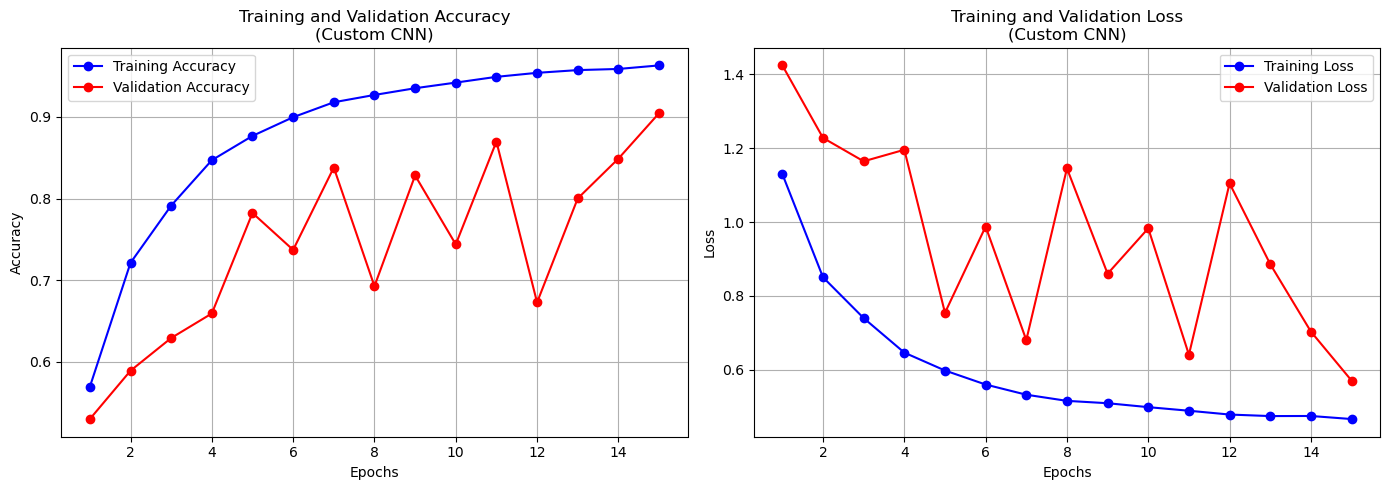

In [29]:
print("Plotting Custom CNN Training History...")
plot_history(history_custom_cnn, "Custom CNN")

Plotting Transfer Learning (Head) Training History...


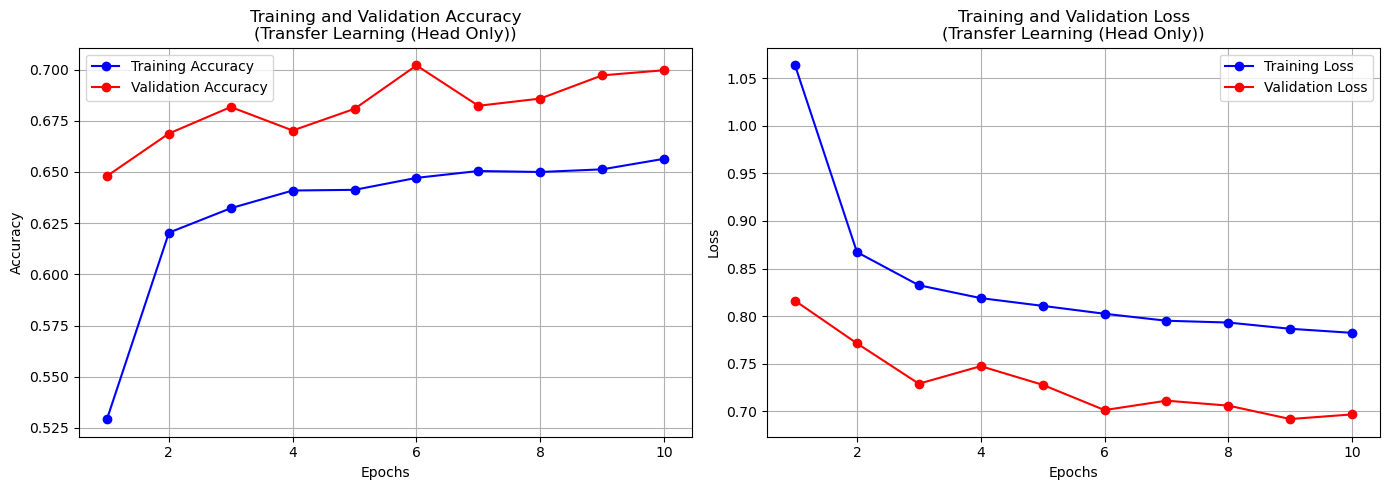

In [ ]:
print("Plotting Transfer Learning (Head) Training History...")
plot_history(history_transfer_head, "Transfer Learning (Head Only)")

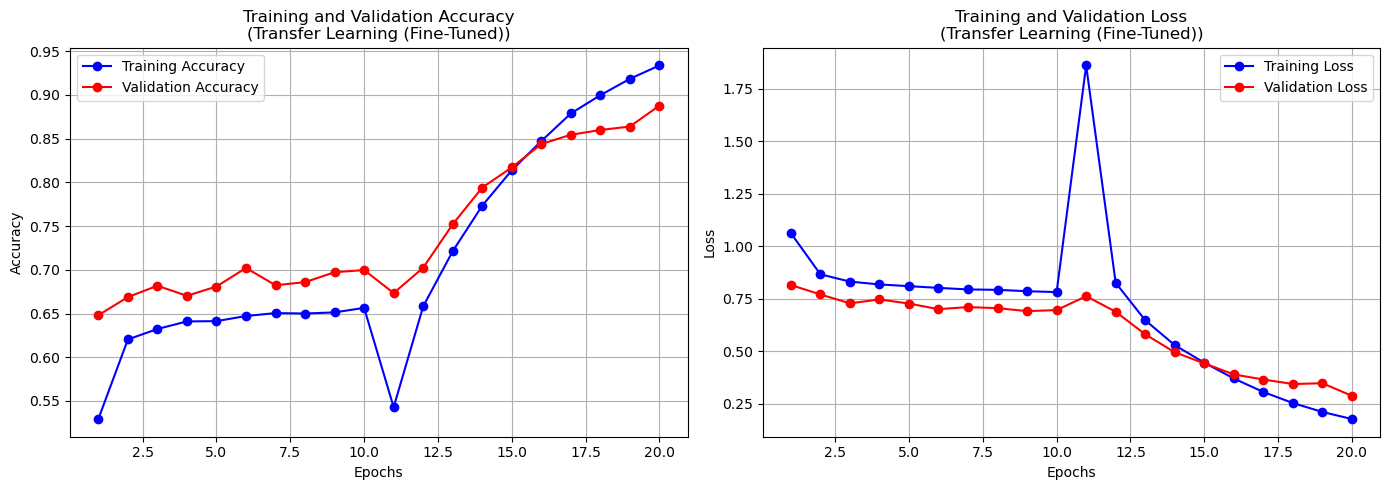

In [ ]:
combined_history = {}
for key in history_transfer_head.history.keys():
   combined_history[key] = history_transfer_head.history[key] + history_fine_tune.history[key]
plot_history(type('obj', (object,), {'history': combined_history})(), "Transfer Learning (Fine-Tuned)")

## 7. Further Steps (Evaluation)<br>
- Evaluate the final models on a separate test set (if available).<br>
- Generate classification reports and confusion matrices.<br>
- Use the trained models to make predictions on new images.